In [2]:
#this is my code to go from an input of T (which I will create in this code) to R values, which is essentially energy exchange rates
#between the DM and baryon matter which will be inputted into CLASS


In [1]:
#for T we want to go from redshift 10e6 to redshift 10e2
#this corresponds to a T of 1e-4 to 5e-10 GeV

import numpy as np
import math
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [2]:
#we will be inputting the mass and temp in GeV for consistency
temps = np.logspace(-10, -1, num=100) #GeV
print(temps)
#this num might seem random, but that is the size of the output of the mathematica code

[1.00000000e-10 1.23284674e-10 1.51991108e-10 1.87381742e-10
 2.31012970e-10 2.84803587e-10 3.51119173e-10 4.32876128e-10
 5.33669923e-10 6.57933225e-10 8.11130831e-10 1.00000000e-09
 1.23284674e-09 1.51991108e-09 1.87381742e-09 2.31012970e-09
 2.84803587e-09 3.51119173e-09 4.32876128e-09 5.33669923e-09
 6.57933225e-09 8.11130831e-09 1.00000000e-08 1.23284674e-08
 1.51991108e-08 1.87381742e-08 2.31012970e-08 2.84803587e-08
 3.51119173e-08 4.32876128e-08 5.33669923e-08 6.57933225e-08
 8.11130831e-08 1.00000000e-07 1.23284674e-07 1.51991108e-07
 1.87381742e-07 2.31012970e-07 2.84803587e-07 3.51119173e-07
 4.32876128e-07 5.33669923e-07 6.57933225e-07 8.11130831e-07
 1.00000000e-06 1.23284674e-06 1.51991108e-06 1.87381742e-06
 2.31012970e-06 2.84803587e-06 3.51119173e-06 4.32876128e-06
 5.33669923e-06 6.57933225e-06 8.11130831e-06 1.00000000e-05
 1.23284674e-05 1.51991108e-05 1.87381742e-05 2.31012970e-05
 2.84803587e-05 3.51119173e-05 4.32876128e-05 5.33669923e-05
 6.57933225e-05 8.111308

In [5]:
#dark matter masses
#as per our conversation, this will be 1/2 MeV to 10MeV
#this translates to 0.0005 to 0.01 GeV

#dmmasses = np.logspace(0.0005, 0.01, num = 399)
#from checking the print statements, this basically writes out y = 10^x for the x being the input
#so it starts at 10^(0.0005) to 10^(0.01), so to get the actual mass values, I should take log(y)
#THIS IS ALSO THE SAME CALCULATION FOR THE TEMPS VARIABLE :) 


In [5]:
#I think what might be convenient now, is to make an array that has each temp and then each g* I don't want to have to 
#figure out how to deal with the temp/g* propogation later
#I will add g*star to the numpy array, or I might have to make a new one, we'll see
#x = standardmodelinfo[:, [1,3]]

In [3]:
#lol I don't need to do all that
#now just need to figure out how to load the file Nirmalya gave me (SHOUTOUT TO HIM)
#CREATING THE GSTAR FILE WITH THE LOW TEMP EXTENSION
my_data = np.genfromtxt('Downloads/T_gstar.dat')
new_rows = np.linspace(2.5e-10, 9.64806010e-06, num = 50)
#print(new_rows)

new_cols = np.ones(len(new_rows))
new_cols = new_cols * 3.36595263e+00
new_data = np.stack((new_rows, new_cols), axis = 1)

combined_data = np.concatenate((new_data, my_data))

In [4]:
def gstar(T):
    gstar = scipy.interpolate.interp1d(combined_data[:,0], combined_data[:,1],bounds_error=False, fill_value=(3.365,106.75))
    return gstar(T)

In [5]:
g_star_today = gstar(2.37e-10)
g_star_rec = gstar(1e-5)
T_eq = 8e-10 #GeV
T_today = 2.37e-10 #GeV
a_eq = 2.9e-4
g_star_eq = gstar(T_eq)
print(gstar(T_eq))

3.36595263


In [6]:
K = g_star_today*(2.37e-10 ** 3)*1
# 2.37e-10 is the CMB temp in GeV
#a = 1 for "TODAY"

In [7]:
def a_value(T):
    g_star_value = gstar(T)
    base_number = (g_star_eq/gstar(T)) ** (1/3)
    
    a_return = base_number * (T_eq/T) * a_eq
    return a_return


Text(0, 0.5, 'Temperatures')

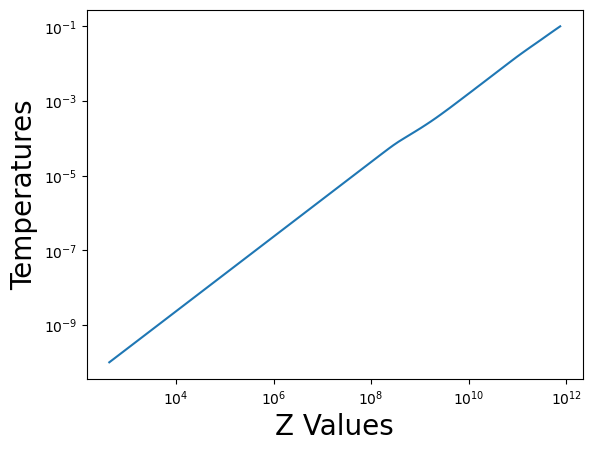

In [9]:
a_values_np = np.frompyfunc(a_value, 1, 1)

a_values_evaluated = a_values_np(temps)
z_values_np = np.frompyfunc(z_value, 1,1 )

z_values = z_values_np(a_values_evaluated)
import matplotlib.pyplot as plt
ax = plt.gca()

plt.plot(z_values, temps)
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel("Z Values", fontsize = 20)
ax.set_ylabel("Temperatures", fontsize = 20)

In [8]:
def z_value(a):
    z = 1/a - 1
    return z

In [15]:
#def rho_value(T):
    #g_star_value = gstar(T)
    #rho_num = (math.pi**2)*g_star_value*(T**4)
    #rho_denom = 30
    #rho = rho_num/rho_denom
    #return rho

In [10]:
def rho(T):
    gStar_value = gstar(T)
    answer = (math.pi*math.pi/30)*gStar_value[0][0]*(T**4)
    return answer

In [16]:
a_check = a_value(1e-2) 
print(a_check)

1.5733088470593483e-11


In [11]:
def H_value(T):
    #making a new H calculation based on the Friedmann Equations
    #first get a from T
    a_values = a_value(T)
    #print(a_values)
    
    #define variables 
    #H0 = 67.37 #km/s/Mpc FROM PLANK
    H0 = 1.4369e-42 #GeV, DOING EVERYTHING IN NATURAL UNITS (used c = 3e8 m/s in calculation)
    
    Omega_r = 8.5e-5
    Omega_lambda = 0.6889
    Omega_m = 0.311
    #sources Plank paper and Prof. Liu notes

    #get H
    H_squared = H0*H0*((Omega_r/(a_values**(4))) + (Omega_m/(a_values**(3))) + Omega_lambda)
    H = math.sqrt(H_squared)
    return H

In [12]:
#a_values_np = np.frompyfunc(a_value, 1, 1)
H_values_np = np.frompyfunc(H_value, 1, 1)

In [13]:
m_planck = 1.22e19 #GeV

def hubble(T):
    rho_value = rho(T)
    answer = math.sqrt((8*math.pi/(3*m_planck*m_planck))*rho_value)
    return answer

In [18]:
print(H_value(2.33e-13)) #temp = 2.7 Kelvins
print(H_value(7.049e-13)) #temp = 8.18 Kelvins (corresponds to z = 2) #this shows good H value for km/s/Mpc H

1.4397251791580666e-42
4.409418704422413e-42


In [14]:
def get_rho(T):
    H_values = H_value(T)
    a_values = a_value(T)

    #did a previous rho check with a rho_crit with the wrong units for the problem I'm currently doing to check with something from Baumann
    
    #rho = (0.311 * 8.07e-47)/(a_values**3)
    rho_crit = (3*1.4369e-42*1.4369e-42)/(8*math.pi*6.70883e-39) #NATURAL UNITS
    rho = (0.05 * rho_crit)/(a_values**3)
    #0.05 is Omega_baryons,0 2.186 from Baumann
    #choosing 0.33 for Omega_m,0 from Plank this allowed me to check with Baumann
    
    return rho

In [20]:
#print(H_value(2.3e-13))
print(H_value(8.67e-10))
#print(a_value(8.67e-10))

2.602723128681798e-37


In [16]:
print(gstar(8.617e-10))

3.36595263


Text(0, 0.5, 'Temperature [GeV]')

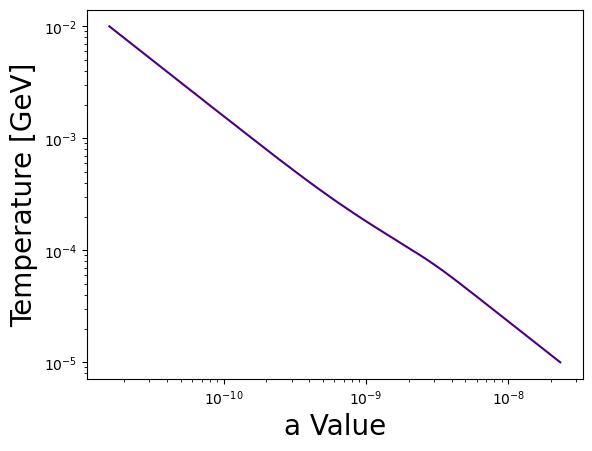

In [30]:
fig = plt.figure()
ax = plt.gca()
T_values = np.logspace(-5, -2, num = 100) #GeV
#g_values = [gstar(T) for T in T_values]
a_values_test = [a_value(T) for T in T_values]
plt.plot(a_values_test, T_values, c='indigo')
plt.xscale('log')
plt.yscale('log')
ax.set_xlabel("a Value", fontsize = 20)
ax.set_ylabel("Temperature [GeV]", fontsize = 20)

In [15]:
#opening the data generated from the mathematica code
#with open("Downloads/massvalues.txt", "r") as file1:
#  masses = np.loadtxt(file1)
#with open('Downloads/sigmavalues.txt', "r") as file2:
#  sigmas = np.loadtxt(file2)
import pandas
#mathematica_data = np.genfromtxt('Downloads/relic_abundance_calc/sigmaBareFullScalar.csv')
#data_test = pandas.read_csv('Downloads/relic_abundance_calc/sigmaBareFullScalar.csv').values
data_test = pandas.read_csv('Downloads/sigmaBareFullScalarAfuracopy.csv').values
masses = data_test[:, [0]]
sigmas = data_test[:, [1]]
#print(sigmas)

In [16]:
# print(temps[1])
def gstar(T):
    gstar = scipy.interpolate.interp1d(combined_data[:,0], combined_data[:,1],bounds_error=False, fill_value=(3.365,106.75))
    return gstar(T)

def sigmaval(m):
    sigmaval = scipy.interpolate.interp1d(masses, sigmas ,bounds_error=False)

In [17]:
#T = INPUT FROM USER
n = 0 #we are doing the n = 0, velocity independent case

Y_b = 1 #mass species fraction (mass is essentially due to proton in atom)

m_b = 0.938 #GeV


c_n_top = 2**(2.5)
c_n_bottom = 3 * math.sqrt(math.pi)
c_n_gamma = math.gamma(3)
c_n = (c_n_top/c_n_bottom) * c_n_gamma #this is a constant

#calculating a value for each temperature

In [18]:
def cn_calc(num):
    c_n_top = 2**((num + 5)/2)
    c_n_bottom = 3 * math.sqrt(math.pi)
    c_n_gamma = math.gamma(3+(num/2))
    c_n = (c_n_top/c_n_bottom) * c_n_gamma #this is a constant
    return c_n

In [21]:
#calculating u
m_b = 0.938 #GeV
m_H = 0.9388 #GeV
v_rms = 10 ** (-8)
def calc_u(T, m, num):
    T_mass_ratio_baryon = T/m_H
    T_mass_ratio_dm = T/m
    v_rms_ratio = (v_rms **2)/3
    base = T_mass_ratio_baryon + T_mass_ratio_dm + v_rms_ratio
    #base = T_mass_ratio_baryon
    u = base**((num+1)/2)
    return u

In [22]:
#calculating sums of masses
def calc_mass_sum(m):
    mass_sum = m + m_H
    #mass_sum = m
    #mass_sum = m #adding to be more accurate to replication
    return mass_sum

In [23]:
#calculating R_chi
#make function
#made some changes, took out a and added 0.76 and 1/H 
def R_chi(T,m, sigma):
    a = a_value(T)
    H = H_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m)
    rho = get_rho(T)
    R_chi_number = (1/mass_sum)*sigma*c_n*u*rho*0.76*(1/H)
    return R_chi_number

In [21]:
def R_chi_test(T,m):
    H = H_value(T)
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m)
    rho = get_rho(T)
    sigma_ratio = 544.646
    R_chi_number = (1/mass_sum)*sigma_ratio*m*1*u*rho*0.76*(1/H)
    return R_chi_number

In [22]:
#NOT USED
def R_chi_test(T,m):
    H = H_value(T)
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m)
    rho = get_rho(T)
    sigma_ratio = 544.646
    R_chi_number = (1/mass_sum)*sigma_ratio*m*c_n*u*rho*0.76*(1/H)
    return R_chi_number

In [23]:
#NOT USED
def R_chi_test2(T,m):
    num = -4
    v = 1e-3
    H = H_value(T)
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m, -4)
    rho = get_rho(T)
    #sigma_ratio = 544.646
    mass_rho_ratio = m/rho
    sigma = 4538.72 #GeV ^-3
    sigma_final = sigma/(v**(num))
    R_chi_number = (1/mass_sum)*sigma_final*m*0.27*u*rho*0.76*(1/H)
    return R_chi_number

In [24]:
R_chi_test_np = np.frompyfunc(R_chi_test, 2, 1)
R_chi_np = np.frompyfunc(R_chi, 3, 1)
R_chi_test2_np = np.frompyfunc(R_chi_test2, 2, 1)

In [25]:
def R_chi_test3(T,m, num):
    #btw this calculates Rx/aH
    #to restore to Rx need to multiply by a and divide by H
    v = 1e-3 #from page 11 of paper this is a ratio with c, in natural units unitless 
    H = H_value(T)
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m, num)
    rho = get_rho(T)
    sigma = 4538.72 #GeV ^-3 from page 11 of paper
    #sigma_final = (sigma*m)/(v**(num))
    sigma_final = (sigma)/(v**(num))
    #print(sigma_final)
    cn_val = cn_calc(num)
    R_chi_number = (1/mass_sum)*sigma_final*cn_val*u*rho*0.76*(1/H)
    #0.76 refers to F_He
    return R_chi_number

In [24]:
def R_chi_test4(T,m, num, sigmaval):
    #btw this calculates Rx/aH
    #to restore to Rx need to multiply by a and divide by H
    v = 1e-3 #from page 11 of paper this is a ratio with c, in natural units unitless 
    H = H_value(T)
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m, num)
    rho = get_rho(T)
    #sigma = 4538.72 #GeV ^-3 from page 11 of paper
    sigma = 8.134776783147942e-09
    sigma_final = (sigma*m)/(v**(num))
    sigma_final = sigmaval
    #print(sigma_final)
    #sigma_final = sigma/(v**(num))
    cn_val = cn_calc(num)
    R_chi_number = (1/mass_sum)*sigma_final*cn_val*u*rho*0.76*(1/H)
    #0.76 refers to F_He
    return R_chi_number

In [26]:
R_chi_test3_np = np.frompyfunc(R_chi_test3, 3, 1)
R_chi_test4_np = np.frompyfunc(R_chi_test4, 4, 1)

In [27]:
#DM MASS of 0.1 GeV
dm_masses = (10**(-3))*np.ones(50)

temps = np.logspace(-10, -4, num=50)

num0 = 0*np.ones(temps.shape)
numminus1 = -1*np.ones(temps.shape)
num1 = 1*np.ones(temps.shape)
numminus2 = -2*np.ones(temps.shape)
num2 = 2*np.ones(temps.shape)
numminus3 = -3*np.ones(temps.shape)
numminus4 = -4*np.ones(temps.shape)

In [70]:
print(temps[0],  dm_masses[0])

1e-10 5.011872336272722


In [ ]:
print(sigmaBareFull(0.75))
print(sigmaBareFull(1e-3))
print(sigmaBareFull(1e-2))
print(sigmaBareFull(1e-1))
8.545324917223926e-15
8.134776783147942e-09
1.1801330539718727e-10
1.570898882928865e-12

In [28]:
dm_masses3 = (1e-3)*np.ones(100)
dm_masses2 = (1e-2)*np.ones(100)
dm_masses1 = (1e-1)*np.ones(100)

temps = np.logspace(-10, 2, num=100)

num0 = 0*np.ones(temps.shape)


Rx_aH_0_test4_3 = R_chi_test4_np(temps, dm_masses3, num0,1.294693938698415e-09)
Rx_aH_0_test4_2 = R_chi_test4_np(temps, dm_masses2, num0,1.878240148525901e-11)
Rx_aH_0_test4_1 = R_chi_test4_np(temps, dm_masses1, num0,2.500163223929614e-13)

In [29]:
Rx_aH_0 = R_chi_test3_np(temps, dm_masses, num0)
Rx_aH_minus1 = R_chi_test3_np(temps, dm_masses, numminus1)
Rx_aH_1 = R_chi_test3_np(temps, dm_masses, num1)
Rx_aH_minus2 = R_chi_test3_np(temps, dm_masses, numminus2)
Rx_aH_2 = R_chi_test3_np(temps, dm_masses, num2)
Rx_aH_minus3 = R_chi_test3_np(temps, dm_masses, numminus3)
Rx_aH_minus4 = R_chi_test3_np(temps, dm_masses, numminus4)

NameError: name 'dm_masses' is not defined

In [29]:
def k_value(a, H):
    k_initial = a*H #[GeV]
    k_secondary = k_initial*1.5637e38 #[1/Mpc]
    k_final = 0.674 * k_secondary
    return k_final

In [30]:
#R_chi_test4_np = np.frompyfunc(R_chi_test4, 4, 1)
k_value_np = np.frompyfunc(k_value, 2, 1)


Text(0.5, 1.0, 'Rx our cross sections')

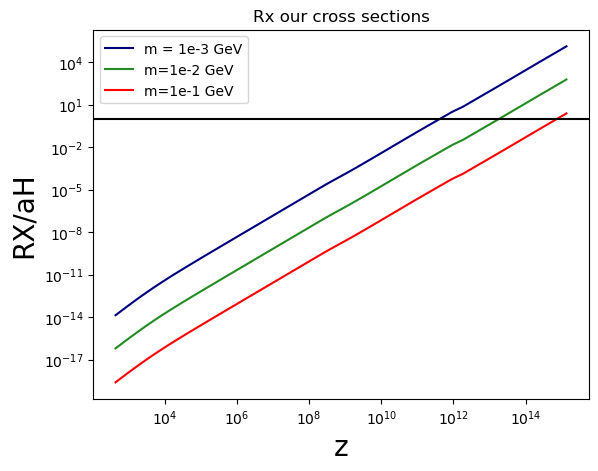

In [34]:
a_values_evaluated = a_values_np(temps)
z_values_np = np.frompyfunc(z_value, 1,1 )
z_values = z_values_np(a_values_evaluated)
H_values_eval = H_values_np(temps)
k_values_eval = k_value_np(a_values_evaluated, H_values_eval)

fig = plt.figure()
ax = plt.gca()
#k_vals_eval = k_value_np(temps)
plt.plot(z_values, Rx_aH_0_test4_3, c='navy', label = 'm = 1e-3 GeV')
plt.plot(z_values, Rx_aH_0_test4_2, c='forestgreen', label = 'm=1e-2 GeV')
plt.plot(z_values, Rx_aH_0_test4_1, c='red', label = 'm=1e-1 GeV')

plt.xscale('log')
plt.yscale('log')
ax.legend() 
#ax.set_ylim(bottom = 0.1, top = 10**(4.5))
#ax.set_xlim(left = 700, right = 10**7)
plt.axhline(y = 1, color = 'black')
ax.set_xlabel("z", fontsize = 20)
ax.set_ylabel("RX/aH", fontsize = 20)
plt.title("Rx our cross sections") 

Text(0.5, 1.0, 'Mx = 1e-3 GeV, fixed mass sum for replication, added our cross section')

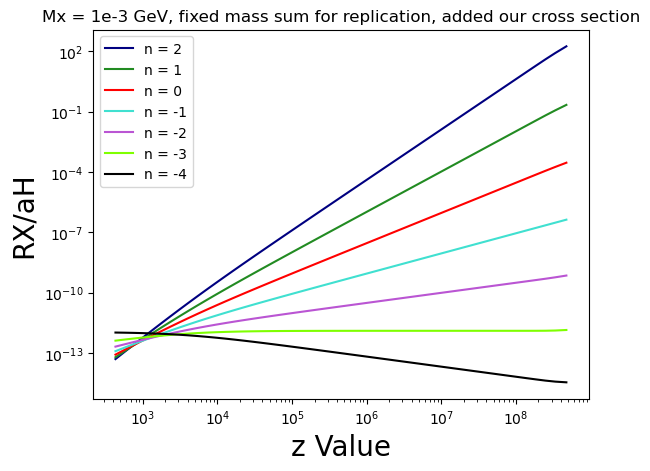

In [64]:
a_values_evaluated = a_values_np(temps)
z_values_np = np.frompyfunc(z_value, 1,1 )
z_values = z_values_np(a_values_evaluated)

fig = plt.figure()
ax = plt.gca()

plt.plot(z_values, Rx_aH_2_test4, c='navy', label = 'n = 2')
plt.plot(z_values, Rx_aH_1_test4, c='forestgreen', label = 'n = 1')
plt.plot(z_values, Rx_aH_0_test4, c='red', label = 'n = 0')
plt.plot(z_values, Rx_aH_minus1_test4, c='turquoise', label = 'n = -1')
plt.plot(z_values, Rx_aH_minus2_test4, c='mediumorchid', label = 'n = -2')
plt.plot(z_values, Rx_aH_minus3_test4, c='chartreuse', label = 'n = -3')
plt.plot(z_values, Rx_aH_minus4_test4, c='black', label = 'n = -4')
plt.xscale('log')
plt.yscale('log')
ax.legend() 
#ax.set_ylim(bottom = 0.1, top = 10**(4.5))
#ax.set_xlim(left = 700, right = 10**7)
ax.set_xlabel("z Value", fontsize = 20)
ax.set_ylabel("RX/aH", fontsize = 20)
plt.title("Mx = 1e-3 GeV, fixed mass sum for replication, added our cross section") 

Text(0.5, 1.0, 'Mx = 10 GeV, fixed mass sum for replication, added right cross section')

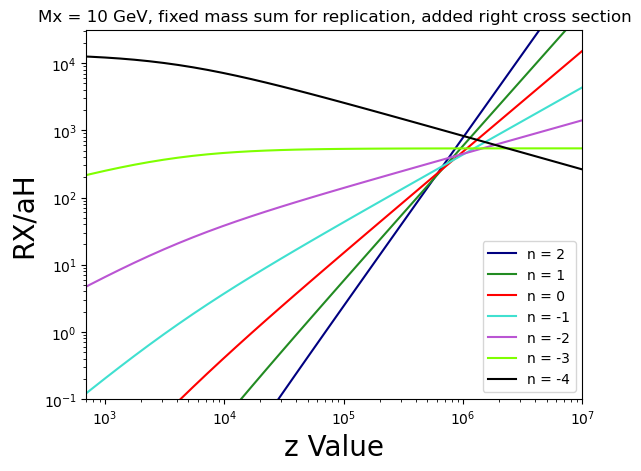

In [33]:
a_values_evaluated = a_values_np(temps)
z_values_np = np.frompyfunc(z_value, 1,1 )
z_values = z_values_np(a_values_evaluated)

fig = plt.figure()
ax = plt.gca()

plt.plot(z_values, Rx_aH_2, c='navy', label = 'n = 2')
plt.plot(z_values, Rx_aH_1, c='forestgreen', label = 'n = 1')
plt.plot(z_values, Rx_aH_0, c='red', label = 'n = 0')
plt.plot(z_values, Rx_aH_minus1, c='turquoise', label = 'n = -1')
plt.plot(z_values, Rx_aH_minus2, c='mediumorchid', label = 'n = -2')
plt.plot(z_values, Rx_aH_minus3, c='chartreuse', label = 'n = -3')
plt.plot(z_values, Rx_aH_minus4, c='black', label = 'n = -4')
plt.xscale('log')
plt.yscale('log')
ax.legend() 
ax.set_ylim(bottom = 0.1, top = 10**(4.5))
ax.set_xlim(left = 700, right = 10**7)
ax.set_xlabel("z Value", fontsize = 20)
ax.set_ylabel("RX/aH", fontsize = 20)
plt.title("Mx = 10 GeV, fixed mass sum for replication, added right cross section") 

Text(0, 0.5, 'RX/aH')

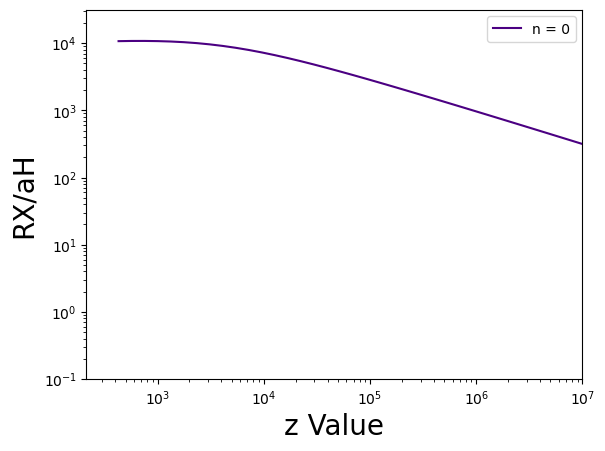

In [85]:
dm_masses = np.logspace(0.7, 2, 50)
#rx_aH = R_chi_test_np(temps, dm_masses)
rx_aH = []
for i in range(len(temps)):
    rx_aH_val = R_chi_test2(temps[i], dm_masses[i])
    rx_aH.append(rx_aH_val)
#rx_aH = R_chi_np(temps, masses,sigmas) 
a_values_evaluated = a_values_np(temps)
z_values_np = np.frompyfunc(z_value, 1,1 )

z_values = z_values_np(a_values_evaluated)

fig = plt.figure()
ax = plt.gca()
plt.plot(z_values, rx_aH, c='indigo', label = 'n = 0')
plt.xscale('log')
plt.yscale('log')
ax.legend() 
ax.set_ylim(bottom = 0.1, top = 10**(4.5))
ax.set_xlim(right = 10**7)
ax.set_xlabel("z Value", fontsize = 20)
ax.set_ylabel("RX/aH", fontsize = 20)

In [20]:
#calculating R_chi_prime
#make function
def R_chi_prime(T,m, sigma):
    a = a_value(T)
    mass_sum = calc_mass_sum(m)
    u = calc_u(T, m)
    rho = get_rho(T)
    R_chi_prime_number = a*(m/mass_sum)*(sigma/mass_sum)*c_n*u*rho
    return R_chi_prime_number

In [21]:
#make R_chi and R_chi_prime arrays
R_chi_list = []
R_chi_prime_list = []
H_list = []
a_list = []
z_list = []
calc_list = []
rho_list = []
sigma_list = []
mass_list = []
u_list = []
for i in range(len(temps)):
    temp = float(temps[i])
    # print(temp)
    mass = float(masses[i][0])
    # print(mass)
    sigma = float(sigmas[i][0])
    # print(sigma)
    H_values = H_value(temp)
    a_values = a_value(temp)
    z_values = z_value(a_values)
    R_chi_num = R_chi(temp, mass, sigma)
    R_chi_prime_num= R_chi_prime(temp, mass, sigma)
    rho_values = get_rho(temp)
    u_values = calc_u(temp, mass)
    R_chi_list.append(R_chi_num)
    R_chi_prime_list.append(R_chi_prime_num)
    H_list.append(H_values)
    a_list.append(a_values)
    z_list.append(z_values)
    u_list.append(u_values)
    calc = R_chi_num/(a_values * H_values)
    calc_list.append(calc)
    rho_list.append(rho_values)
    mass_list.append(mass)
    sigma_list.append(sigma)

Text(0, 0.5, '$\\sigma$')

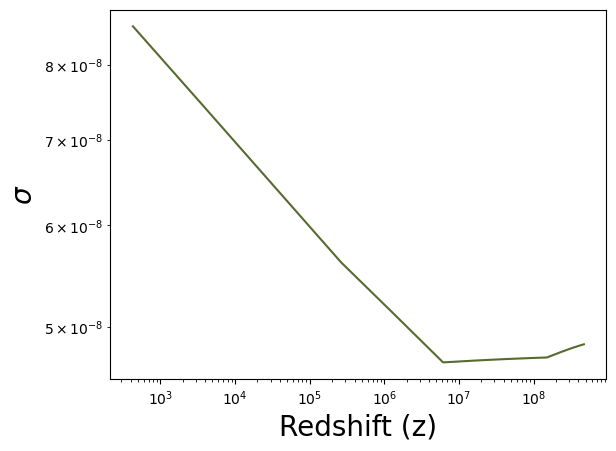

In [24]:
fig = plt.figure()
ax = plt.gca()
#plt.plot(z_list, H_list, c = 'black')
plt.plot(z_list, sigma_list, c = 'darkolivegreen')
#plt.plot(z_list, calc_list, c = 'darkmagenta')
#plt.plot(z_list, rho_list, c = 'royalblue')
plt.xscale('log')
plt.yscale('log')
#ax.xaxis.set_inverted(True)
ax.set_xlabel("Redshift (z)", fontsize = 20)
#ax.set_xlabel("a", fontsize = 20)
#ax.set_ylabel("T", fontsize = 20)
#ax.set_ylabel("$R_\chi$ /aH", fontsize = 20)
#plt.xlim(1e3, 1e7) 
#plt.ylim(1e-1, 1e4)
#ax.set_ylabel("$\u03C1$ for baryons", fontsize = 20)
ax.set_ylabel("$\sigma$", fontsize = 20)
#ax.set_ylabel("U", fontsize = 20)

In [22]:
R_chi_array = np.array(R_chi_list)
R_chi_prime_array = np.array(R_chi_prime_list)
H_array = np.array(H_list)

print(R_chi_array.shape)
print(R_chi_prime_array.shape)
print(masses[:,0].shape)
print(temps.shape)
output_data = np.stack((masses[:,0], temps, R_chi_array, R_chi_prime_array), axis = 1)
print(output_data)

(371,)
(371,)
(371,)
(371,)
[[5.05242645e-04 1.00000000e-10 1.81069492e-43 9.74784424e-47]
 [5.09330871e-04 1.03804508e-10 1.81906698e-43 9.87211252e-47]
 [5.13452178e-04 1.07753760e-10 1.82743492e-43 9.99773032e-47]
 ...
 [9.80618314e-03 9.28041864e-05 8.66928849e-45 8.96941085e-47]
 [9.88553095e-03 9.63349295e-05 8.40947091e-45 8.77026626e-47]
 [9.96552080e-03 1.00000000e-04 8.15157169e-45 8.56936834e-47]]


In [28]:
np.savetxt("dataout.txt", (masses, temps, R_chi, R_chi_prime), header = "masses, temps, R_chi, R_chi_prime")

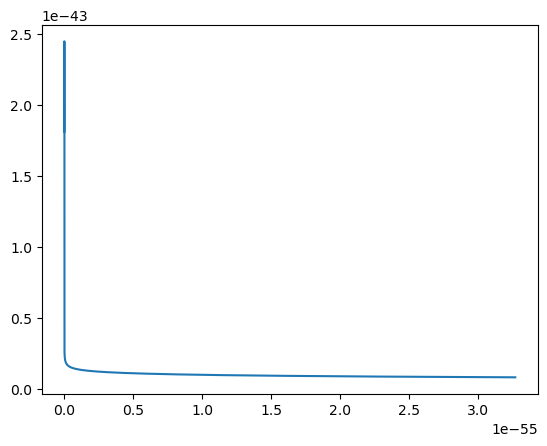

In [29]:
plt.plot(H_array, R_chi_array)
#plt.plot(temps, H_array)